In [1]:
!pip install scikit-learn
!pip install tensorflow


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

In [213]:
df = pd.read_csv("datasets.csv") 
df.head()

,Unnamed: 0,text,sentiment
0,43956,Развода на деньги нет\nНаблюдаюсь в Лайфклиник...,1
1,17755,Отель выбрали потому что рядом со стадионом. О...,0
2,20269,"Вылечили\nГноился с рождения глазик, в поликли...",1
3,16648,Хорошее расположение.С вокзала дошли пешком.Но...,0
4,27879,"Отличное месторасположение,прекрасный вид,особ...",1


In [214]:
df = pd.concat([
    df[df["sentiment"] == 0].sample(n=30000, random_state=42),
    df[df["sentiment"] == 1].sample(n=30000, random_state=42),
    df[df["sentiment"] == 2].sample(n=30000, random_state=42),
]).reset_index(drop=True)
df = df.drop(columns=["Unnamed: 0"])
df = df.sample(frac=1, ignore_index=True)
df

,text,sentiment
0,"Идея Паба хорошая , место - не плохое , интерь...",0
1,"Рекомендуем выбрать этот отель, так как он оче...",0
2,Отношение\nМы с мужем и старшим сыночком перее...,2
3,"отель нам продавали как 4-ку, но,конечно, это ...",0
4,Заведение было выбрано по территориальному при...,0
...,...,...
89995,Шли бы вы куда подальше со своими вбросами. Су...,2
89996,Никогда не ходите туда\nДелал там зуб. Во-перв...,2
89997,А вот и в штатах на границе с Мексикой е....ло...,1
89998,"Заехали в Отель 15.01.2018 года! На ресепшене,...",0


In [215]:
df["sentiment"].value_counts()

sentiment
0    30000
2    30000
1    30000
Name: count, dtype: int64

# Векторизация и One-hot encdoing

In [216]:
vectorizer = TfidfVectorizer(max_features=3000, ngram_range=(1,2))
X = vectorizer.fit_transform(df["text"]).toarray()
y = df["sentiment"].values

X.shape

(90000, 3000)

In [217]:
y_cat = to_categorical(y, num_classes=3) 

# Разбиение на обучающую и тестовые выборки и стандартизация

In [218]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, random_state=42, stratify=y
)

In [219]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train

array([[-0.12912599, -0.07844033, -0.07309649, ..., -0.061717  ,
        -0.10221708, -0.06560703],
       [-0.12912599, -0.07844033, -0.07309649, ..., -0.061717  ,
        -0.10221708, -0.06560703],
       [-0.12912599, -0.07844033, -0.07309649, ..., -0.061717  ,
        -0.10221708, -0.06560703],
       ...,
       [-0.12912599, -0.07844033, -0.07309649, ..., -0.061717  ,
        -0.10221708, -0.06560703],
       [-0.12912599, -0.07844033, -0.07309649, ..., -0.061717  ,
        -0.10221708, -0.06560703],
       [-0.12912599, -0.07844033, -0.07309649, ..., -0.061717  ,
        -0.10221708, -0.06560703]], shape=(72000, 3000))

# Реализация Early stopping

In [220]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Модели

## 1 модель (самая простая)

In [221]:
model1 = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(3, activation='softmax')
])

model1.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history1 = model1.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

C:\Users\mlbel\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
1800/1800 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6859 - loss: 0.6962 - val_accuracy: 0.7128 - val_loss: 0.6192
Epoch 2/15
1800/1800 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7763 - loss: 0.5163 - val_accuracy: 0.7125 - val_loss: 0.6344
Epoch 3/15
1800/1800 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8250 - loss: 0.4198 - val_accuracy: 0.7083 - val_loss: 0.6935
Epoch 4/15
1800/1800 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8811 - loss: 0.3053 - val_accuracy: 0.7018 - val_loss: 0.8624


# 2 модель с реализацией DropOut

In [222]:
model2 = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dropout(0.7),
    layers.Dense(64, activation='relu'),
    layers.Dense(3, activation='softmax')
])
model2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
history2 = model2.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/15
1800/1800 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.6110 - loss: 0.8608 - val_accuracy: 0.7100 - val_loss: 0.6581
Epoch 2/15
1800/1800 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7024 - loss: 0.6555 - val_accuracy: 0.7164 - val_loss: 0.6240
Epoch 3/15
1800/1800 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7222 - loss: 0.6162 - val_accuracy: 0.7167 - val_loss: 0.6176
Epoch 4/15
1800/1800 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7377 - loss: 0.5872 - val_accuracy: 0.7178 - val_loss: 0.6117
Epoch 5/15
1800/1800 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7482 - loss: 0.5663 - val_accuracy: 0.7243 - val_loss: 0.6050
Epoch 6/15
1800/1800 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7582 - loss: 0.5459 - val_accuracy: 0.7224 - val_loss: 0.6090
Epoch 7/15
1800/1800 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7679 - loss: 0.5287 - val_accuracy: 0.7172 - val_loss: 0.6148
Epoch 8/15
1800/1800 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7766 - loss: 0.5140 - 

## 3 модель (3 промежуточных слоя с двумя dropout)

In [223]:
model3 = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dropout(0.7),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(64, activation='relu'),
    layers.Dense(3, activation='softmax')
])

model3.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history3 = model3.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/15
1800/1800 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.5837 - loss: 0.8908 - val_accuracy: 0.6972 - val_loss: 0.6909
Epoch 2/15
1800/1800 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.6935 - loss: 0.6800 - val_accuracy: 0.7085 - val_loss: 0.6461
Epoch 3/15
1800/1800 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.7189 - loss: 0.6296 - val_accuracy: 0.7128 - val_loss: 0.6356


# Функции с метриками и график обучения

In [224]:
def evaluate_model(model, X_test, y_test):
    y_pred_probs = model.predict(X_test, verbose=0)
    # Берём класс с максимальной вероятностью
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.argmax(y_test, axis=1)
    
    f1  = f1_score(y_true, y_pred, average='macro')
    pre = precision_score(y_true, y_pred, average='macro')
    rec = recall_score(y_true, y_pred, average='macro')
    print(f"F1-score:  {f1:.4f}")
    print(f"Precision: {pre:.4f}")
    print(f"Recall:    {rec:.4f}")
    return f1, pre, rec

In [225]:
def plot_history(history, title="Model"):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy
    ax1.plot(history.history['accuracy'], linewidth=2, label='Train Accuracy')
    ax1.plot(history.history['val_accuracy'], linewidth=2, label='Validation Accuracy')
    ax1.set_title(f'{title}: Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Loss
    ax2.plot(history.history['loss'], linewidth=2, label='Train Loss')
    ax2.plot(history.history['val_loss'], linewidth=2, label='Validation Loss')
    ax2.set_title(f'{title}: Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Модель 1

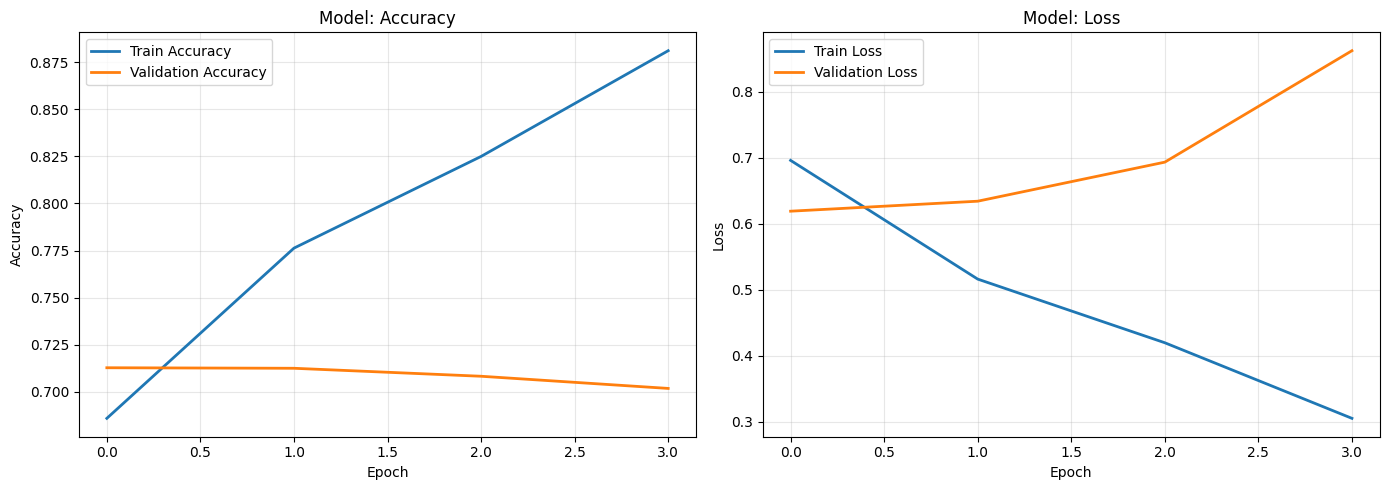

F1-score:  0.7150
Precision: 0.7160
Recall:    0.7153


(0.714972369592333, 0.7160347953924225, 0.7153333333333333)

In [226]:
plot_history(history1)
evaluate_model(model1, X_test, y_test)

# Модель 2

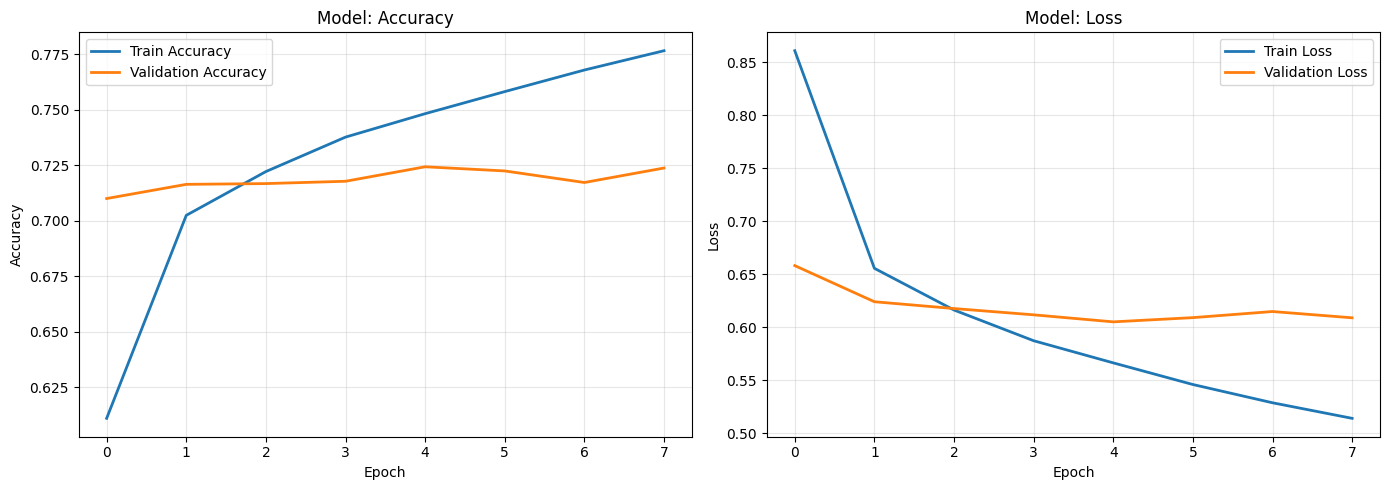

F1-score:  0.7165
Precision: 0.7442
Recall:    0.7188


(0.7164685188792238, 0.7442276746765192, 0.7187777777777778)

In [227]:
plot_history(history2)
evaluate_model(model2, X_test, y_test)

# Модель 3

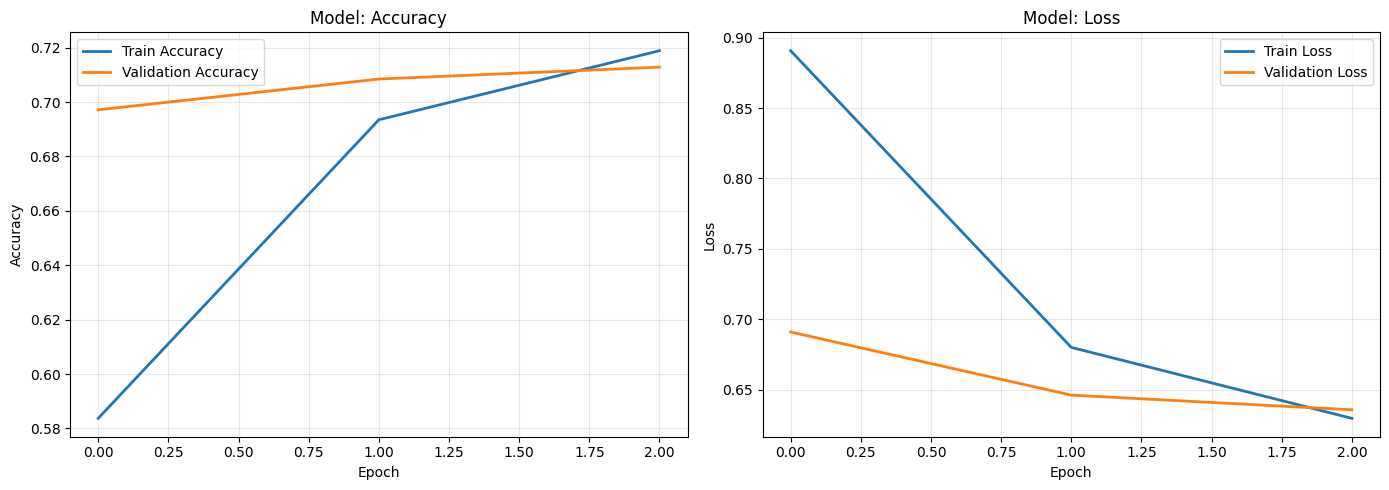

F1-score:  0.6878
Precision: 0.7330
Recall:    0.6925


(0.6877797649719327, 0.73295695039226, 0.6925)

In [228]:
plot_history(history3)
evaluate_model(model3, X_test, y_test)